# Supplementary Figure 12: fitting Hill function to single-timepoint data to calculate input chemical concentrations

We derive the following expression to calculate input $x$ (chemical concentration) from output $y$ (fluorescence readout value) for our datasets. 
$$
y(x) = r_0 + k \frac{x^n}{K^n + x^n}
$$

$$
f = \frac{y - r_0}{k} = \frac{x^n}{K^n + x^n}
$$

$$
x^n = \frac{f}{1-f} K^n
$$

$$
\boxed{x = K \left( \frac{f}{1-f} \right)^{1/n}}
$$

After Hill function parameters $K$, $n$, $r_0$, $k$ are fitted to the dose response data, we will plug the fitted parameter values into the expression derived above and use it to perform the inverse problem and determine $x$ from $y$. 

## Import necessary packages

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import glob
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# katie_revs_analysis/mechanistic_model_as_dec4edit.py
#import data loading and pre-processing functions from separate .py files
from data_loading_v5 import define_metadata, import_exp_data, filter_dataframes, process_dataframes, convert_reader_data, subtract,normalize
from plot_timecourses import plottimecourselist, plottimecoursearray, figure_layout 
from crosstalk import crosstalk, mixed_crosstalk, antibiotic_crosstalk, mixed_crosstalk_more_inputs
from dose_response_fitting import dose_response_fitting_more_inputs_hills12

## Supplementary Figure 12a: aTc-IPTG dataset transfer function fitting

### Process and plot data

In [2]:
#select which microbial community dataset to work with
community='aTc_IPTG' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_iptg_kan_cm_glucose'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

if community=='antibiotic_data':
    od_conv=od_raws
    fp1_conv=fp1_raws
    fp2_conv=fp2_raws
    fp3_conv=None
else:
    # convert the plate reader data to match based on calibrations
    od_conv=convert_reader_data(readers, None, od_raws,community)
    fp1_conv=convert_reader_data(readers, fluor1, fp1_raws,community)
    fp2_conv=convert_reader_data(readers, fluor2, fp2_raws,community)
    if sensors==3:
        fp3_conv=convert_reader_data(readers, fluor3, fp3_raws,community)
    else:
        fp3_conv=None

# Subtract basal expression (sample with 0 inducers added) time course from all time courses of the same experiment 
subtracted_fp1_conv_all, subtracted_fp2_conv_all, subtracted_fp3_conv_all=subtract(community,time_vector,fp1_conv,fp2_conv,fp3_conv,sensors,input_arrays)

# Min-max scale each fluorescence time course to be on a scale from 0-1
normalized_fp1_conv_all, normalized_fp2_conv_all, normalized_fp3_conv_all=normalize(subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all)

#Append the full OD and fluorescence timecourses from the normalized dataset
#stack the OD time courses to be in the same format the fluorescence curves are
od_stack=np.empty((0,len(time_vector)), dtype=float)
for i, reader in enumerate(fluor1):
    od_stack=np.vstack((od_stack,od_conv[i]))
# Initialize the list of arrays to concatenate
concat_list = [od_stack]
#append each time course
concat_list.append(normalized_fp1_conv_all)
concat_list.append(normalized_fp2_conv_all)
if normalized_fp3_conv_all is not None and normalized_fp3_conv_all.size>0:  # Check if fp3 is None
    concat_list.append(normalized_fp3_conv_all)
exp_data_new=np.concatenate(concat_list,axis=1)
    
#concatenate all experimental input data into one array
exp_inputs=np.vstack(list(input_arrays.values())) #used to be normalized_input_arrays

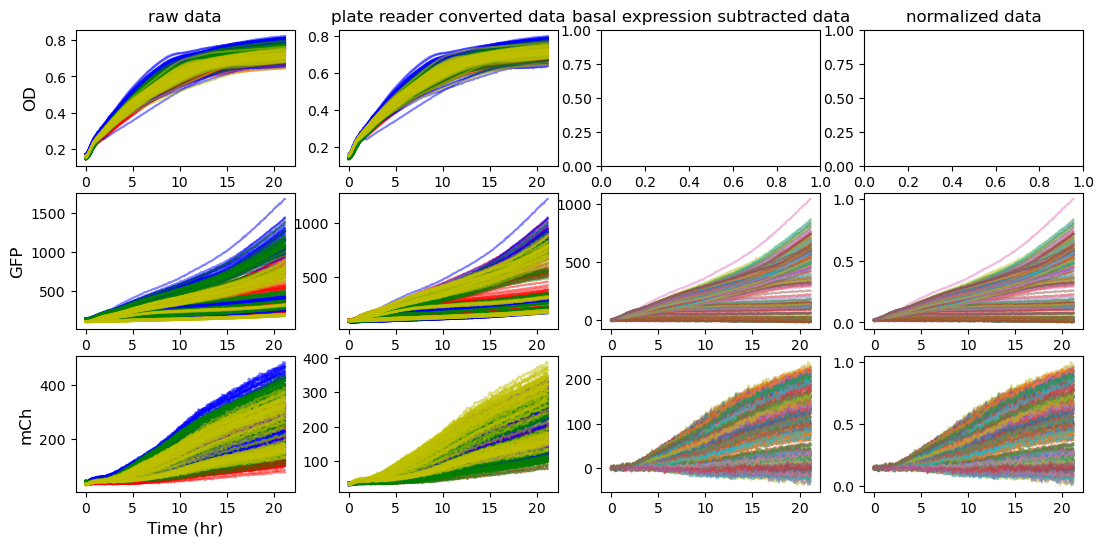

In [3]:
# Plot raw, converted, subtracted (full basal timecourse is subtracted), normalized
#Plot the time courses after each step of pre-processing
if sensors==2:
    rawlists=[od_raws,fp1_raws,fp2_raws]
    convlists=[od_conv,fp1_conv,fp2_conv]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all]
else:
    rawlists=[od_raws,fp1_raws,fp2_raws,fp3_raws]
    convlists=[od_conv,fp1_conv,fp2_conv,fp3_raws]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all,normalized_fp3_conv_all]

figure_layout(sensors,rawlists,convlists,subtractedarrays,normalizedarrays,time_vector,fluors)

#save figure
if community=='antibiotic_data':
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
else:
    save_dir = f"figures/{community}/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f'{save_dir}timecourse processing.svg',format='svg')

### Calculate, save crosstalk (alpha) values from t=20

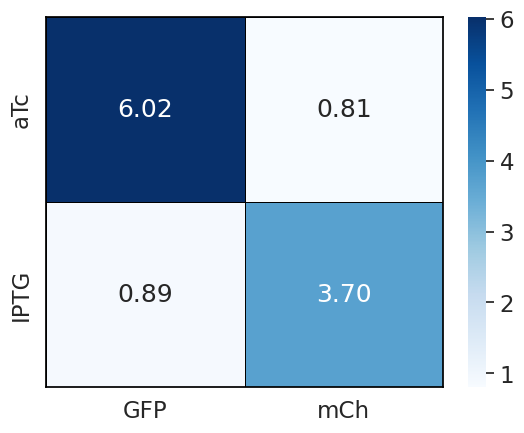

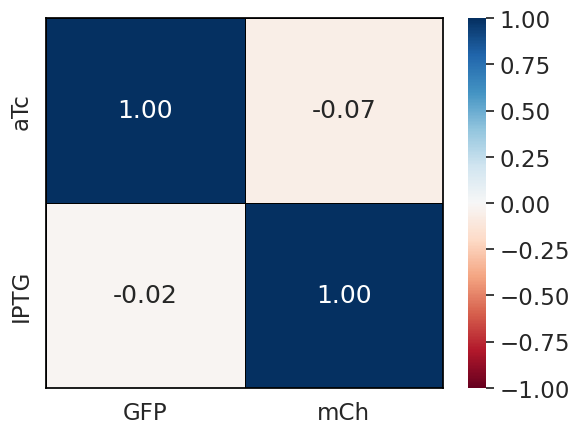

In [4]:
'''crosstalk calculation from mixed culture data'''
#Choose time point to calculate alpha from 
timepoint=20 #define desired hours of interest 

#perform function to calculate alphas and plot crosstalk heatmap
#for antibiotic sensor communities:
if community=='antibiotic_data':
    alphas,fig=antibiotic_crosstalk(timepoint,time_vector,files,od_raws,fp1_raws,fp2_raws,fluors)
    #save figure
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
elif community=='ttr_iptg_kan_cm_glucose':
    file=files[0]
    #df_try = mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    alphas,fig,df_try=mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
else:
    #for regular sensor communities
    if ((community=='aTc_IPTG')|(community=='TTR_THS')):
        file=files[0]
    elif community=='cuma_ohc_atc':
        file=files[2]
    elif ((community=='van_dapg_nar')|(community=='atc_van')):
        file=files[1]
    else:
        file=files[1]
    alphas,fig=mixed_crosstalk(file,sensors,timepoint,fluors)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')

In [5]:
#don't run this cell if we already have the alphas saved from previously
#save parameters
datestamp = datetime.now().strftime("%Y-%m-%d") # Format: YYYY-MM-DD
if community=='antibiotic_data':
    save_dir = f"parameter_files/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
else:
    save_dir = f"parameter_files/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
    
np.save(filename, alphas)

### Fit dose response data to Hill function, then carry out the inverse problem to estimate inputs from outputs and plot results
#### (We include added functionality to perform this calculation at multiple timepoints, to show robustness of these results. However, for this figure, we only perform analysis with t=20)

In [6]:
def predict_x_from_y(y, r0, k, K, n, clip=True, eps=1e-9):
    y = np.asarray(y)
    f = (y - r0) / k
    if clip:
        f = np.clip(f, eps, 1 - eps)
    x_pred = K * (f / (1 - f)) ** (1 / n)
    return x_pred

def fit_hill(timepoint, filt_exp_inputs, fluor_data, num_inputs, num_fluors, fluor_inds, param_inds, remove_od_len):
    
    filtered_x=filt_exp_inputs
    filtered_y=fluor_data

    # determine the parameters from ALL data
    K_calc, hill_calc,r0_calc, k_calc,fig=dose_response_fitting_more_inputs_hills12(timepoint, exp_inputs, normalized_fp1_conv_all, 
                                                                            normalized_fp2_conv_all, normalized_fp3_conv_all, 
                                                                            time_vector, input_names, sensors, fluors,community,
                                                                            plasmid,inhibitor)
    all_hill_preds=np.zeros((num_inputs,filtered_x.shape[0]))
    
    for i in range(num_inputs):

        #calculate timepoint 
        fi=fluor_inds[i]
        timeloc = (np.abs(time_vector - timepoint)).argmin()  # defines location of that time
        fluor_range=list(range(fi*remove_od_len, (fi+1)*remove_od_len))
        fluor_time=fluor_range[timeloc]
        
        y=filtered_y[:,fluor_time]
        pi=param_inds[i]
        hill_pred=predict_x_from_y(y, r0_calc[pi], k_calc[pi], K_calc[pi], hill_calc[pi])
        
        all_hill_preds[i]=hill_pred

    fig, axes = plt.subplots(
        1, num_inputs,
        figsize=(3.75 * num_inputs, 3),
        sharey=False
        )

    if num_inputs == 1:
        axes = [axes]

    edge_thresh = 1.0  # decades

    for i in range(num_inputs):
        ax = axes[i]

        x_true = filtered_x[:, i]
        x_pred = all_hill_preds[i]

        # remove negative predictions
        valid = (x_true > 0) & (x_pred > 0)
        x_true = x_true[valid]
        x_pred = x_pred[valid]

        x_true_log = np.log10(x_true)
        x_pred_log = np.log10(x_pred)

        # identify edge cases
        log_err = np.abs(x_pred_log - x_true_log)
        is_edge = log_err > edge_thresh
        is_clean = ~is_edge

        # calculate r2 score for all points and non-edge points 
        r2_all = r2_score(x_true_log, x_pred_log)
        if np.sum(is_clean) > 1:
            r2_clean = r2_score(
                x_true_log[is_clean],
                x_pred_log[is_clean]
            )
        else:
            r2_clean = np.nan

        # plot true vs. predicted concentrations 
        # non-edge points 
        ax.scatter(
            x_true_log[is_clean],
            x_pred_log[is_clean],
            s=15,
            color='blue',
            alpha=0.7,
            label='Normal'
        )

        # edge points 
        ax.scatter(
            x_true_log[is_edge],
            x_pred_log[is_edge],
            s=15,
            color='red',
            alpha=0.8,
            label='Edge case'
        )

        # plot y=x
        min_val = min(x_true_log.min(), x_pred_log.min())
        max_val = max(x_true_log.max(), x_pred_log.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='gray')
        
        pad = 0.15
        ax.set_xlim(min_val - pad, max_val + pad)
        ax.set_ylim(min_val - pad, max_val + pad)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(r'True log(' + input_names[i] + ')', fontsize=12)
        ax.set_ylabel(r'Predicted log(' + input_names[i] + ')', fontsize=12)

        ax.text(
            0.05, 0.95,
            f'R$^2$ = {r2_all:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='red'
        )

        ax.text(
            0.05, 0.87,
            f'R$^2$ = {r2_clean:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='blue'
        )


    plt.tight_layout()
    plt.show()

    return all_hill_preds

def fit_hill_multiple_timepoints(timepoints, filtered_exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len):
    
    all_preds_dict = {}
    
    for t in timepoints:
        print(f"Processing timepoint: {t}")
        preds = fit_hill(
            timepoint=t,
            filt_exp_inputs=filtered_exp_inputs,
            fluor_data=fluor_data,
            num_inputs=num_inputs,
            num_fluors=num_fluors,
            fluor_inds=fluor_inds,
            param_inds=param_inds, 
            remove_od_len=remove_od_len
        )
        all_preds_dict[t] = preds
        
    return all_preds_dict


Processing timepoint: 20


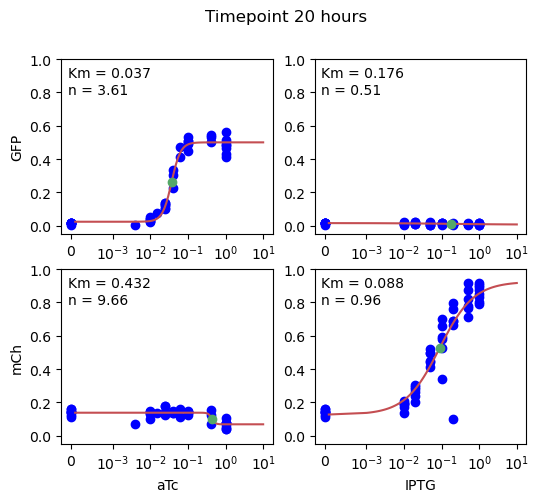

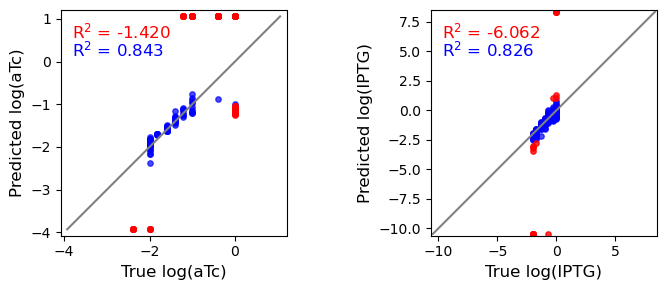

In [7]:
timepoints=[20]
num_inputs=2
num_fluors=2
fluor_inds=[0,1]
param_inds=[0,3]

remove_od_len=int(exp_data_new.shape[1]/(num_fluors+1))
fluor_data=exp_data_new[:,remove_od_len:]

hill_results=fit_hill_multiple_timepoints(timepoints, exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len)

## Supplementary Figure 12b: TTR-THS dataset transfer function fitting

### Process and plot data 

In [8]:
#select which microbial community dataset to work with
community='TTR_THS' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_iptg_kan_cm_glucose'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

if community=='antibiotic_data':
    od_conv=od_raws
    fp1_conv=fp1_raws
    fp2_conv=fp2_raws
    fp3_conv=None
else:
    # convert the plate reader data to match based on calibrations
    od_conv=convert_reader_data(readers, None, od_raws,community)
    fp1_conv=convert_reader_data(readers, fluor1, fp1_raws,community)
    fp2_conv=convert_reader_data(readers, fluor2, fp2_raws,community)
    if sensors==3:
        fp3_conv=convert_reader_data(readers, fluor3, fp3_raws,community)
    else:
        fp3_conv=None

# Subtract basal expression (sample with 0 inducers added) time course from all time courses of the same experiment 
subtracted_fp1_conv_all, subtracted_fp2_conv_all, subtracted_fp3_conv_all=subtract(community,time_vector,fp1_conv,fp2_conv,fp3_conv,sensors,input_arrays)

# Min-max scale each fluorescence time course to be on a scale from 0-1
normalized_fp1_conv_all, normalized_fp2_conv_all, normalized_fp3_conv_all=normalize(subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all)

#Append the full OD and fluorescence timecourses from the normalized dataset
#stack the OD time courses to be in the same format the fluorescence curves are
od_stack=np.empty((0,len(time_vector)), dtype=float)
for i, reader in enumerate(fluor1):
    od_stack=np.vstack((od_stack,od_conv[i]))
# Initialize the list of arrays to concatenate
concat_list = [od_stack]
#append each time course
concat_list.append(normalized_fp1_conv_all)
concat_list.append(normalized_fp2_conv_all)
if normalized_fp3_conv_all is not None and normalized_fp3_conv_all.size>0:  # Check if fp3 is None
    concat_list.append(normalized_fp3_conv_all)
exp_data_new=np.concatenate(concat_list,axis=1)
    
#concatenate all experimental input data into one array
exp_inputs=np.vstack(list(input_arrays.values())) #used to be normalized_input_arrays

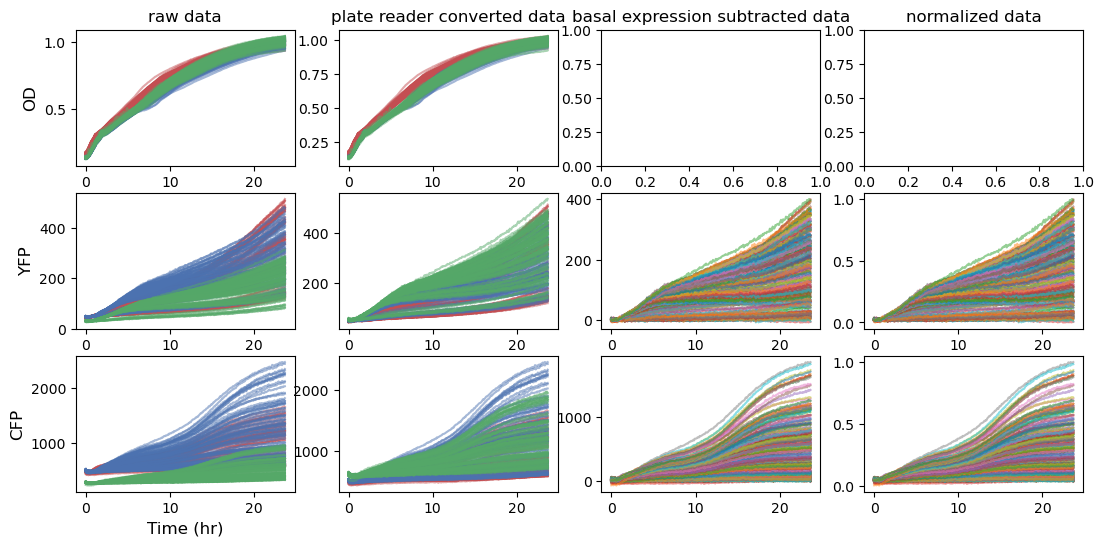

In [9]:
# Plot raw, converted, subtracted (full basal timecourse is subtracted), normalized
#Plot the time courses after each step of pre-processing
if sensors==2:
    rawlists=[od_raws,fp1_raws,fp2_raws]
    convlists=[od_conv,fp1_conv,fp2_conv]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all]
else:
    rawlists=[od_raws,fp1_raws,fp2_raws,fp3_raws]
    convlists=[od_conv,fp1_conv,fp2_conv,fp3_raws]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all,normalized_fp3_conv_all]

figure_layout(sensors,rawlists,convlists,subtractedarrays,normalizedarrays,time_vector,fluors)

#save figure
if community=='antibiotic_data':
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
else:
    save_dir = f"figures/{community}/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f'{save_dir}timecourse processing.svg',format='svg')

### Calculate, save crosstalk (alpha) values from t=20

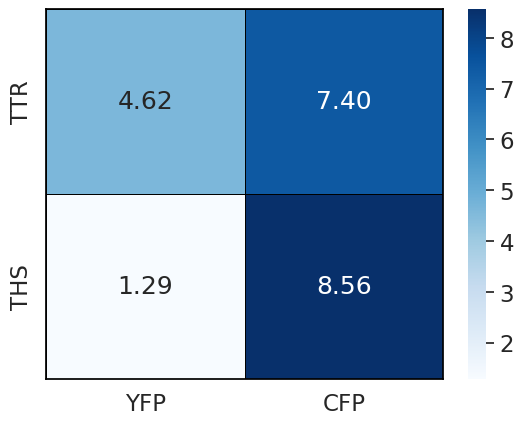

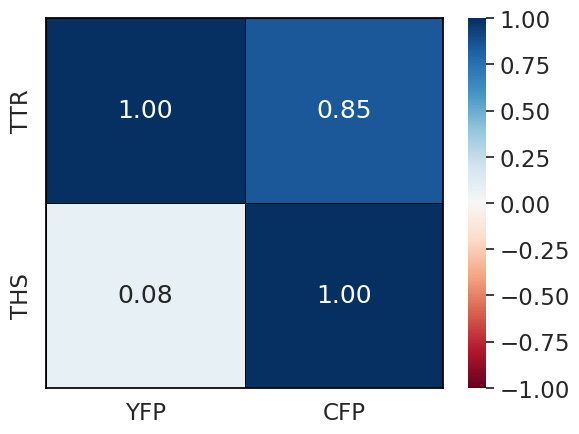

In [10]:
'''crosstalk calculation from mixed culture data'''
#Choose time point to calculate alpha from 
timepoint=20 #define desired hours of interest 

#perform function to calculate alphas and plot crosstalk heatmap
#for antibiotic sensor communities:
if community=='antibiotic_data':
    alphas,fig=antibiotic_crosstalk(timepoint,time_vector,files,od_raws,fp1_raws,fp2_raws,fluors)
    #save figure
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
elif community=='ttr_iptg_kan_cm_glucose':
    file=files[0]
    #df_try = mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    alphas,fig,df_try=mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
else:
    #for regular sensor communities
    if ((community=='aTc_IPTG')|(community=='TTR_THS')):
        file=files[0]
    elif community=='cuma_ohc_atc':
        file=files[2]
    elif ((community=='van_dapg_nar')|(community=='atc_van')):
        file=files[1]
    else:
        file=files[1]
    alphas,fig=mixed_crosstalk(file,sensors,timepoint,fluors)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')

In [11]:
#don't run this cell if we already have the alphas saved from previously
#save parameters
datestamp = datetime.now().strftime("%Y-%m-%d") # Format: YYYY-MM-DD
if community=='antibiotic_data':
    save_dir = f"parameter_files/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
else:
    save_dir = f"parameter_files/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
    
np.save(filename, alphas)

### Fit dose response data to Hill function, then carry out the inverse problem to estimate inputs from outputs and plot results
#### (We include added functionality to perform this calculation at multiple timepoints, to show robustness of these results. However, for this figure, we only perform analysis with t=20)

In [12]:
def predict_x_from_y(y, r0, k, K, n, clip=True, eps=1e-9):
    y = np.asarray(y)
    f = (y - r0) / k
    if clip:
        f = np.clip(f, eps, 1 - eps)
    x_pred = K * (f / (1 - f)) ** (1 / n)
    return x_pred

def fit_hill(timepoint, filt_exp_inputs, fluor_data, num_inputs, num_fluors, fluor_inds, param_inds, remove_od_len):
    
    filtered_x=filt_exp_inputs
    filtered_y=fluor_data

    # determine the parameters from ALL data
    K_calc, hill_calc,r0_calc, k_calc,fig=dose_response_fitting_more_inputs_hills12(timepoint, exp_inputs, normalized_fp1_conv_all, 
                                                                            normalized_fp2_conv_all, normalized_fp3_conv_all, 
                                                                            time_vector, input_names, sensors, fluors,community,
                                                                            plasmid,inhibitor)
    all_hill_preds=np.zeros((num_inputs,filtered_x.shape[0]))
    
    for i in range(num_inputs):

        #calculate timepoint 
        fi=fluor_inds[i]
        timeloc = (np.abs(time_vector - timepoint)).argmin()  # defines location of that time
        fluor_range=list(range(fi*remove_od_len, (fi+1)*remove_od_len))
        fluor_time=fluor_range[timeloc]
        
        y=filtered_y[:,fluor_time]
        pi=param_inds[i]
        hill_pred=predict_x_from_y(y, r0_calc[pi], k_calc[pi], K_calc[pi], hill_calc[pi])
        
        all_hill_preds[i]=hill_pred

    fig, axes = plt.subplots(
        1, num_inputs,
        figsize=(3.75 * num_inputs, 3),
        sharey=False
        )

    if num_inputs == 1:
        axes = [axes]

    edge_thresh = 1.0  # decades

    for i in range(num_inputs):
        ax = axes[i]

        x_true = filtered_x[:, i]
        x_pred = all_hill_preds[i]

        # remove negative predictions
        valid = (x_true > 0) & (x_pred > 0)
        x_true = x_true[valid]
        x_pred = x_pred[valid]

        x_true_log = np.log10(x_true)
        x_pred_log = np.log10(x_pred)

        # identify edge cases
        log_err = np.abs(x_pred_log - x_true_log)
        is_edge = log_err > edge_thresh
        is_clean = ~is_edge

        # calculate r2 score for all points and non-edge points 
        r2_all = r2_score(x_true_log, x_pred_log)
        if np.sum(is_clean) > 1:
            r2_clean = r2_score(
                x_true_log[is_clean],
                x_pred_log[is_clean]
            )
        else:
            r2_clean = np.nan

        # plot true vs. predicted concentrations 
        # non-edge points 
        ax.scatter(
            x_true_log[is_clean],
            x_pred_log[is_clean],
            s=15,
            color='blue',
            alpha=0.7,
            label='Normal'
        )

        # edge points 
        ax.scatter(
            x_true_log[is_edge],
            x_pred_log[is_edge],
            s=15,
            color='red',
            alpha=0.8,
            label='Edge case'
        )

        # plot y=x
        min_val = min(x_true_log.min(), x_pred_log.min())
        max_val = max(x_true_log.max(), x_pred_log.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='gray')
        
        pad = 0.15
        ax.set_xlim(min_val - pad, max_val + pad)
        ax.set_ylim(min_val - pad, max_val + pad)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(r'True log(' + input_names[i] + ')', fontsize=12)
        ax.set_ylabel(r'Predicted log(' + input_names[i] + ')', fontsize=12)

        ax.text(
            0.05, 0.95,
            f'R$^2$ = {r2_all:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='red'
        )

        ax.text(
            0.05, 0.87,
            f'R$^2$ = {r2_clean:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='blue'
        )


    plt.tight_layout()
    plt.show()

    return all_hill_preds

def fit_hill_multiple_timepoints(timepoints, filtered_exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len):
    
    all_preds_dict = {}
    
    for t in timepoints:
        print(f"Processing timepoint: {t}")
        preds = fit_hill(
            timepoint=t,
            filt_exp_inputs=filtered_exp_inputs,
            fluor_data=fluor_data,
            num_inputs=num_inputs,
            num_fluors=num_fluors,
            fluor_inds=fluor_inds,
            param_inds=param_inds, 
            remove_od_len=remove_od_len
        )
        all_preds_dict[t] = preds
        
    return all_preds_dict


Processing timepoint: 20


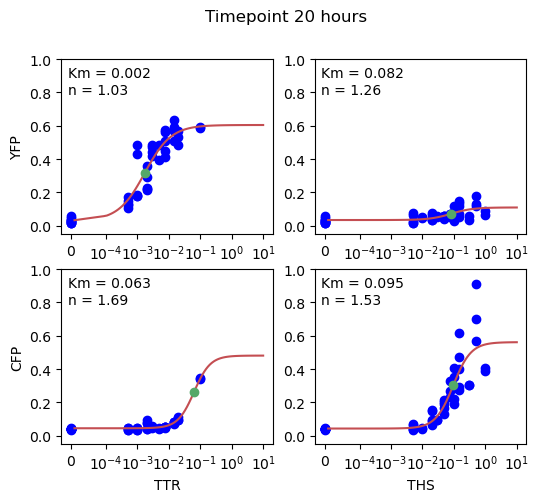

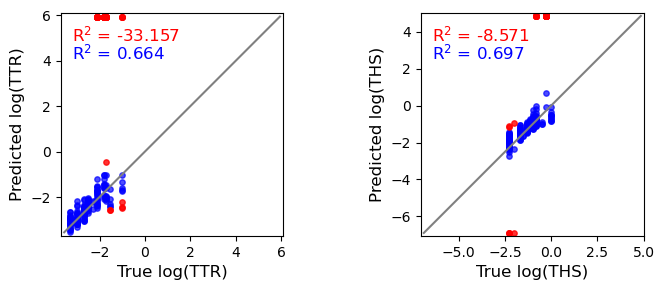

In [13]:
timepoints=[20]
num_inputs=2
num_fluors=2
fluor_inds=[0, 1]
param_inds=[0,3]

remove_od_len=int(exp_data_new.shape[1]/(num_fluors+1))
fluor_data=exp_data_new[:,remove_od_len:]

hill_results=fit_hill_multiple_timepoints(timepoints, exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len)

## Supplementary Figure 12c: cuma-ohc14-aTc dataset transfer function fitting

### Process and plot data 

In [14]:
#select which microbial community dataset to work with
community='cuma_ohc_atc' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_iptg_kan_cm_glucose'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

if community=='antibiotic_data':
    od_conv=od_raws
    fp1_conv=fp1_raws
    fp2_conv=fp2_raws
    fp3_conv=None
else:
    # convert the plate reader data to match based on calibrations
    od_conv=convert_reader_data(readers, None, od_raws,community)
    fp1_conv=convert_reader_data(readers, fluor1, fp1_raws,community)
    fp2_conv=convert_reader_data(readers, fluor2, fp2_raws,community)
    if sensors==3:
        fp3_conv=convert_reader_data(readers, fluor3, fp3_raws,community)
    else:
        fp3_conv=None

# Subtract basal expression (sample with 0 inducers added) time course from all time courses of the same experiment 
subtracted_fp1_conv_all, subtracted_fp2_conv_all, subtracted_fp3_conv_all=subtract(community,time_vector,fp1_conv,fp2_conv,fp3_conv,sensors,input_arrays)

# Min-max scale each fluorescence time course to be on a scale from 0-1
normalized_fp1_conv_all, normalized_fp2_conv_all, normalized_fp3_conv_all=normalize(subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all)

#Append the full OD and fluorescence timecourses from the normalized dataset
#stack the OD time courses to be in the same format the fluorescence curves are
od_stack=np.empty((0,len(time_vector)), dtype=float)
for i, reader in enumerate(fluor1):
    od_stack=np.vstack((od_stack,od_conv[i]))
# Initialize the list of arrays to concatenate
concat_list = [od_stack]
#append each time course
concat_list.append(normalized_fp1_conv_all)
concat_list.append(normalized_fp2_conv_all)
if normalized_fp3_conv_all is not None and normalized_fp3_conv_all.size>0:  # Check if fp3 is None
    concat_list.append(normalized_fp3_conv_all)
exp_data_new=np.concatenate(concat_list,axis=1)
    
#concatenate all experimental input data into one array
exp_inputs=np.vstack(list(input_arrays.values())) #used to be normalized_input_arrays

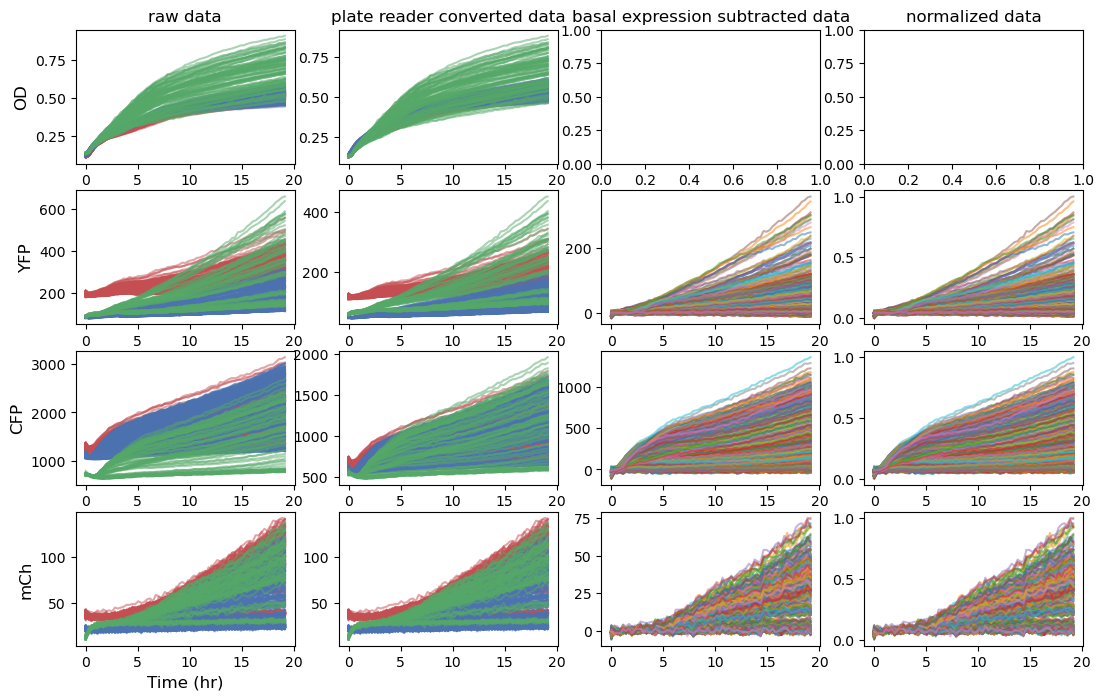

In [15]:
# Plot raw, converted, subtracted (full basal timecourse is subtracted), normalized
#Plot the time courses after each step of pre-processing
if sensors==2:
    rawlists=[od_raws,fp1_raws,fp2_raws]
    convlists=[od_conv,fp1_conv,fp2_conv]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all]
else:
    rawlists=[od_raws,fp1_raws,fp2_raws,fp3_raws]
    convlists=[od_conv,fp1_conv,fp2_conv,fp3_raws]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all,normalized_fp3_conv_all]

figure_layout(sensors,rawlists,convlists,subtractedarrays,normalizedarrays,time_vector,fluors)

#save figure
if community=='antibiotic_data':
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
else:
    save_dir = f"figures/{community}/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f'{save_dir}timecourse processing.svg',format='svg')

### Calculate, save crosstalk (alpha) values from t=20

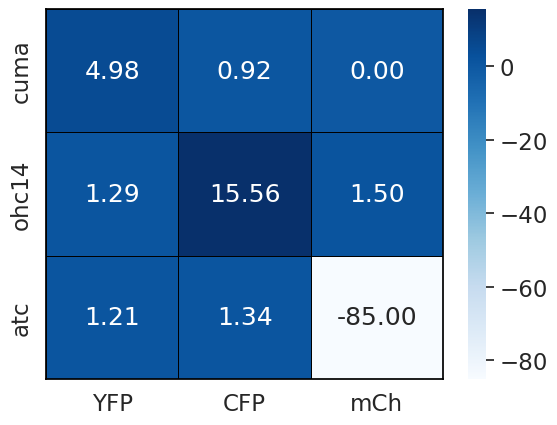

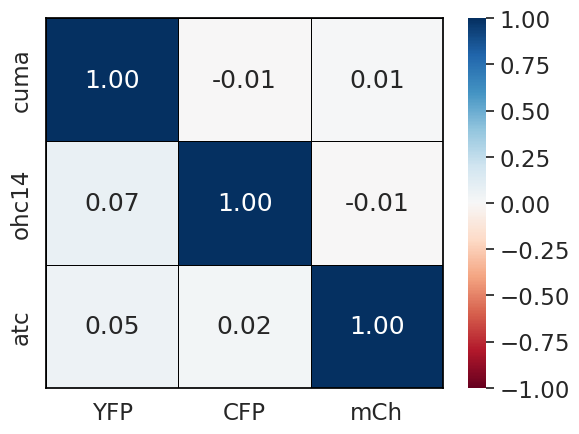

In [16]:
'''crosstalk calculation from mixed culture data'''
#Choose time point to calculate alpha from 
timepoint=20 #define desired hours of interest 

#perform function to calculate alphas and plot crosstalk heatmap
#for antibiotic sensor communities:
if community=='antibiotic_data':
    alphas,fig=antibiotic_crosstalk(timepoint,time_vector,files,od_raws,fp1_raws,fp2_raws,fluors)
    #save figure
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
elif community=='ttr_iptg_kan_cm_glucose':
    file=files[0]
    #df_try = mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    alphas,fig,df_try=mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
else:
    #for regular sensor communities
    if ((community=='aTc_IPTG')|(community=='TTR_THS')):
        file=files[0]
    elif community=='cuma_ohc_atc':
        file=files[2]
    elif ((community=='van_dapg_nar')|(community=='atc_van')):
        file=files[1]
    else:
        file=files[1]
    alphas,fig=mixed_crosstalk(file,sensors,timepoint,fluors)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')

In [17]:
#don't run this cell if we already have the alphas saved from previously
#save parameters
datestamp = datetime.now().strftime("%Y-%m-%d") # Format: YYYY-MM-DD
if community=='antibiotic_data':
    save_dir = f"parameter_files/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
else:
    save_dir = f"parameter_files/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
    
np.save(filename, alphas)

### Fit dose response data to Hill function, then carry out the inverse problem to estimate inputs from outputs and plot results
#### (We include added functionality to perform this calculation at multiple timepoints, to show robustness of these results. However, for this figure, we only perform analysis with t=20)

In [18]:
def predict_x_from_y(y, r0, k, K, n, clip=True, eps=1e-9):
    y = np.asarray(y)
    f = (y - r0) / k
    if clip:
        f = np.clip(f, eps, 1 - eps)
    x_pred = K * (f / (1 - f)) ** (1 / n)
    return x_pred

def fit_hill(timepoint, filt_exp_inputs, fluor_data, num_inputs, num_fluors, fluor_inds, param_inds, remove_od_len):
    
    filtered_x=filt_exp_inputs
    filtered_y=fluor_data

    # determine the parameters from ALL data
    K_calc, hill_calc,r0_calc, k_calc,fig=dose_response_fitting_more_inputs_hills12(timepoint, exp_inputs, normalized_fp1_conv_all, 
                                                                            normalized_fp2_conv_all, normalized_fp3_conv_all, 
                                                                            time_vector, input_names, sensors, fluors,community,
                                                                            plasmid,inhibitor)
    all_hill_preds=np.zeros((num_inputs,filtered_x.shape[0]))
    
    for i in range(num_inputs):

        #calculate timepoint 
        fi=fluor_inds[i]
        timeloc = (np.abs(time_vector - timepoint)).argmin()  # defines location of that time
        fluor_range=list(range(fi*remove_od_len, (fi+1)*remove_od_len))
        fluor_time=fluor_range[timeloc]
        
        y=filtered_y[:,fluor_time]
        pi=param_inds[i]
        hill_pred=predict_x_from_y(y, r0_calc[pi], k_calc[pi], K_calc[pi], hill_calc[pi])
        
        all_hill_preds[i]=hill_pred

    fig, axes = plt.subplots(
        1, num_inputs,
        figsize=(3.75 * num_inputs, 3),
        sharey=False
        )

    if num_inputs == 1:
        axes = [axes]

    edge_thresh = 1.0  # decades

    for i in range(num_inputs):
        ax = axes[i]

        x_true = filtered_x[:, i]
        x_pred = all_hill_preds[i]

        # remove negative predictions
        valid = (x_true > 0) & (x_pred > 0)
        x_true = x_true[valid]
        x_pred = x_pred[valid]

        x_true_log = np.log10(x_true)
        x_pred_log = np.log10(x_pred)

        # identify edge cases
        log_err = np.abs(x_pred_log - x_true_log)
        is_edge = log_err > edge_thresh
        is_clean = ~is_edge

        # calculate r2 score for all points and non-edge points 
        r2_all = r2_score(x_true_log, x_pred_log)
        if np.sum(is_clean) > 1:
            r2_clean = r2_score(
                x_true_log[is_clean],
                x_pred_log[is_clean]
            )
        else:
            r2_clean = np.nan

        # plot true vs. predicted concentrations 
        # non-edge points 
        ax.scatter(
            x_true_log[is_clean],
            x_pred_log[is_clean],
            s=15,
            color='blue',
            alpha=0.7,
            label='Normal'
        )

        # edge points 
        ax.scatter(
            x_true_log[is_edge],
            x_pred_log[is_edge],
            s=15,
            color='red',
            alpha=0.8,
            label='Edge case'
        )

        # plot y=x
        min_val = min(x_true_log.min(), x_pred_log.min())
        max_val = max(x_true_log.max(), x_pred_log.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='gray')
        
        pad = 0.15
        ax.set_xlim(min_val - pad, max_val + pad)
        ax.set_ylim(min_val - pad, max_val + pad)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(r'True log(' + input_names[i] + ')', fontsize=12)
        ax.set_ylabel(r'Predicted log(' + input_names[i] + ')', fontsize=12)

        ax.text(
            0.05, 0.95,
            f'R$^2$ = {r2_all:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='red'
        )

        ax.text(
            0.05, 0.87,
            f'R$^2$ = {r2_clean:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='blue'
        )


    plt.tight_layout()
    plt.show()

    return all_hill_preds

def fit_hill_multiple_timepoints(timepoints, filtered_exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len):
    
    all_preds_dict = {}
    
    for t in timepoints:
        print(f"Processing timepoint: {t}")
        preds = fit_hill(
            timepoint=t,
            filt_exp_inputs=filtered_exp_inputs,
            fluor_data=fluor_data,
            num_inputs=num_inputs,
            num_fluors=num_fluors,
            fluor_inds=fluor_inds,
            param_inds=param_inds, 
            remove_od_len=remove_od_len
        )
        all_preds_dict[t] = preds
        
    return all_preds_dict


Processing timepoint: 20


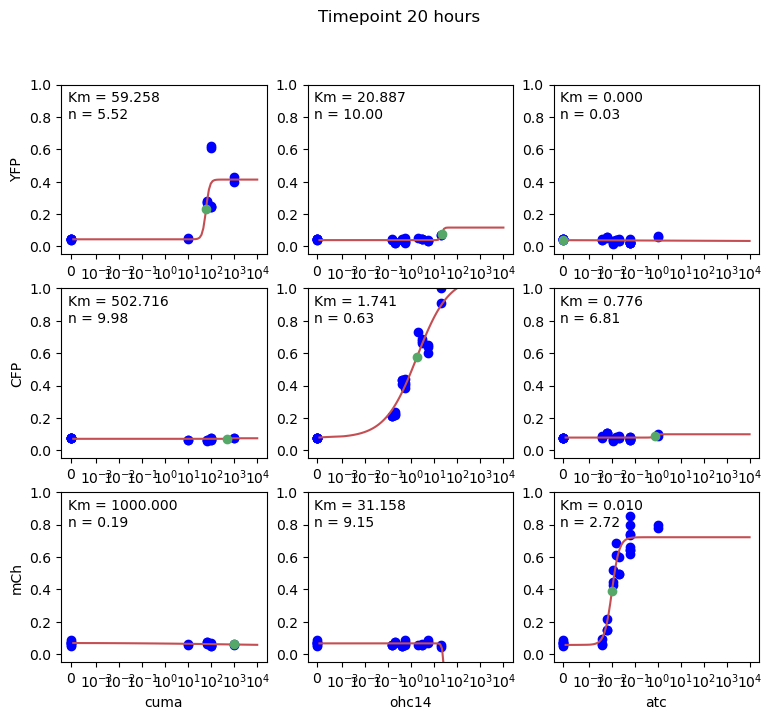

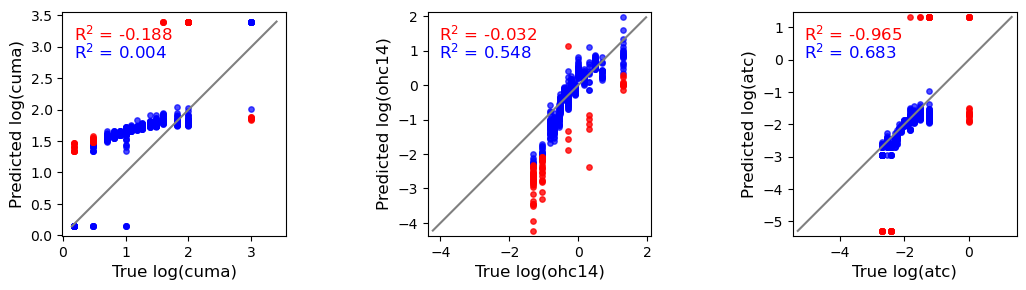

In [19]:
timepoints=[20]
num_inputs=3
num_fluors=3
fluor_inds=[0,1,2]
param_inds=[0,4,8]

remove_od_len=int(exp_data_new.shape[1]/(num_fluors+1))
fluor_data=exp_data_new[:,remove_od_len:]

hill_results=fit_hill_multiple_timepoints(timepoints, exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len)

## Supplementary Figure 12d: van-dapg-nar dataset transfer function fitting

### Process and plot data

In [21]:
#select which microbial community dataset to work with
community='van_dapg_nar' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_iptg_kan_cm_glucose'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

if community=='antibiotic_data':
    od_conv=od_raws
    fp1_conv=fp1_raws
    fp2_conv=fp2_raws
    fp3_conv=None
else:
    # convert the plate reader data to match based on calibrations
    od_conv=convert_reader_data(readers, None, od_raws,community)
    fp1_conv=convert_reader_data(readers, fluor1, fp1_raws,community)
    fp2_conv=convert_reader_data(readers, fluor2, fp2_raws,community)
    if sensors==3:
        fp3_conv=convert_reader_data(readers, fluor3, fp3_raws,community)
    else:
        fp3_conv=None

# Subtract basal expression (sample with 0 inducers added) time course from all time courses of the same experiment 
subtracted_fp1_conv_all, subtracted_fp2_conv_all, subtracted_fp3_conv_all=subtract(community,time_vector,fp1_conv,fp2_conv,fp3_conv,sensors,input_arrays)

# Min-max scale each fluorescence time course to be on a scale from 0-1
normalized_fp1_conv_all, normalized_fp2_conv_all, normalized_fp3_conv_all=normalize(subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all)

#Append the full OD and fluorescence timecourses from the normalized dataset
#stack the OD time courses to be in the same format the fluorescence curves are
od_stack=np.empty((0,len(time_vector)), dtype=float)
for i, reader in enumerate(fluor1):
    od_stack=np.vstack((od_stack,od_conv[i]))
# Initialize the list of arrays to concatenate
concat_list = [od_stack]
#append each time course
concat_list.append(normalized_fp1_conv_all)
concat_list.append(normalized_fp2_conv_all)
if normalized_fp3_conv_all is not None and normalized_fp3_conv_all.size>0:  # Check if fp3 is None
    concat_list.append(normalized_fp3_conv_all)
exp_data_new=np.concatenate(concat_list,axis=1)
    
#concatenate all experimental input data into one array
exp_inputs=np.vstack(list(input_arrays.values())) #used to be normalized_input_arrays

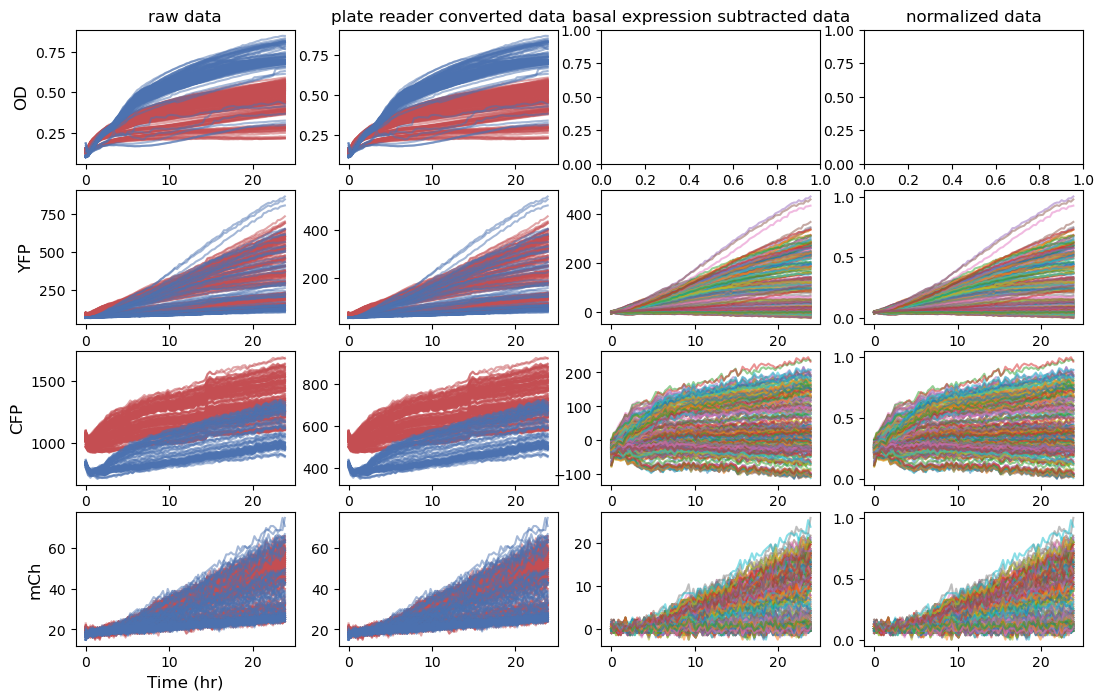

In [22]:
# Plot raw, converted, subtracted (full basal timecourse is subtracted), normalized
#Plot the time courses after each step of pre-processing
if sensors==2:
    rawlists=[od_raws,fp1_raws,fp2_raws]
    convlists=[od_conv,fp1_conv,fp2_conv]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all]
else:
    rawlists=[od_raws,fp1_raws,fp2_raws,fp3_raws]
    convlists=[od_conv,fp1_conv,fp2_conv,fp3_raws]
    subtractedarrays=[subtracted_fp1_conv_all,subtracted_fp2_conv_all,subtracted_fp3_conv_all]
    normalizedarrays=[normalized_fp1_conv_all,normalized_fp2_conv_all,normalized_fp3_conv_all]

figure_layout(sensors,rawlists,convlists,subtractedarrays,normalizedarrays,time_vector,fluors)

#save figure
if community=='antibiotic_data':
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
else:
    save_dir = f"figures/{community}/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f'{save_dir}timecourse processing.svg',format='svg')

### Calculate, save crosstalk (alpha) values from t=20

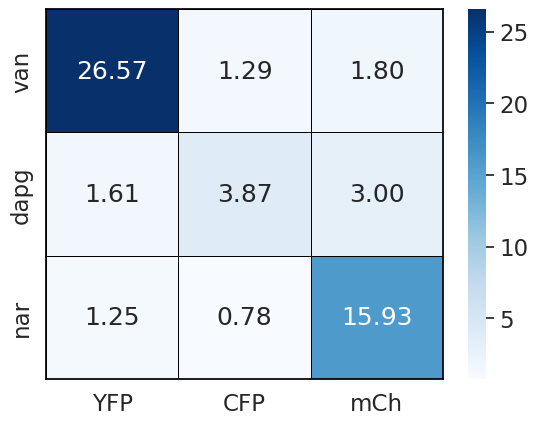

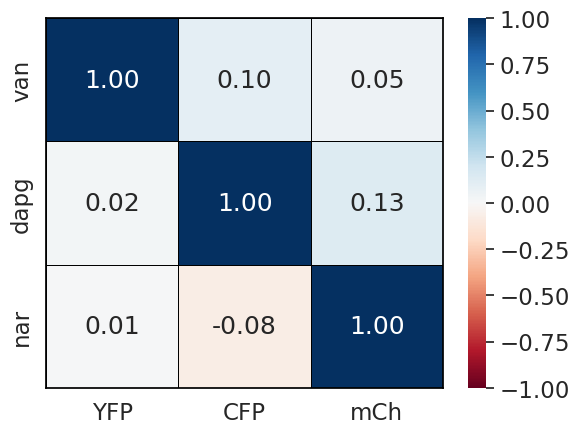

In [23]:
'''crosstalk calculation from mixed culture data'''
#Choose time point to calculate alpha from 
timepoint=20 #define desired hours of interest 

#perform function to calculate alphas and plot crosstalk heatmap
#for antibiotic sensor communities:
if community=='antibiotic_data':
    alphas,fig=antibiotic_crosstalk(timepoint,time_vector,files,od_raws,fp1_raws,fp2_raws,fluors)
    #save figure
    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
elif community=='ttr_iptg_kan_cm_glucose':
    file=files[0]
    #df_try = mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    alphas,fig,df_try=mixed_crosstalk_more_inputs(file,sensors,timepoint,fluors,input_names)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')
else:
    #for regular sensor communities
    if ((community=='aTc_IPTG')|(community=='TTR_THS')):
        file=files[0]
    elif community=='cuma_ohc_atc':
        file=files[2]
    elif ((community=='van_dapg_nar')|(community=='atc_van')):
        file=files[1]
    else:
        file=files[1]
    alphas,fig=mixed_crosstalk(file,sensors,timepoint,fluors)
    #save figure
    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')

In [24]:
#don't run this cell if we already have the alphas saved from previously
#save parameters
datestamp = datetime.now().strftime("%Y-%m-%d") # Format: YYYY-MM-DD
if community=='antibiotic_data':
    save_dir = f"parameter_files/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
else:
    save_dir = f"parameter_files/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    filename= f"{save_dir}{datestamp}_{timepoint}hr_{community}_alphas_mixed.npy"
    
np.save(filename, alphas)

### Fit dose response data to Hill function, then carry out the inverse problem to estimate inputs from outputs and plot results
#### (We include added functionality to perform this calculation at multiple timepoints, to show robustness of these results. However, for this figure, we only perform analysis with t=20)

In [25]:
def predict_x_from_y(y, r0, k, K, n, clip=True, eps=1e-9):
    y = np.asarray(y)
    f = (y - r0) / k
    if clip:
        f = np.clip(f, eps, 1 - eps)
    x_pred = K * (f / (1 - f)) ** (1 / n)
    return x_pred

def fit_hill(timepoint, filt_exp_inputs, fluor_data, num_inputs, num_fluors, fluor_inds, param_inds, remove_od_len):
    
    filtered_x=filt_exp_inputs
    filtered_y=fluor_data

    # determine the parameters from ALL data
    K_calc, hill_calc,r0_calc, k_calc,fig=dose_response_fitting_more_inputs_hills12(timepoint, exp_inputs, normalized_fp1_conv_all, 
                                                                            normalized_fp2_conv_all, normalized_fp3_conv_all, 
                                                                            time_vector, input_names, sensors, fluors,community,
                                                                            plasmid,inhibitor)
    all_hill_preds=np.zeros((num_inputs,filtered_x.shape[0]))
    
    for i in range(num_inputs):

        #calculate timepoint 
        fi=fluor_inds[i]
        timeloc = (np.abs(time_vector - timepoint)).argmin()  # defines location of that time
        fluor_range=list(range(fi*remove_od_len, (fi+1)*remove_od_len))
        fluor_time=fluor_range[timeloc]
        
        y=filtered_y[:,fluor_time]
        pi=param_inds[i]
        hill_pred=predict_x_from_y(y, r0_calc[pi], k_calc[pi], K_calc[pi], hill_calc[pi])
        
        all_hill_preds[i]=hill_pred

    fig, axes = plt.subplots(
        1, num_inputs,
        figsize=(3.75 * num_inputs, 3),
        sharey=False
        )

    if num_inputs == 1:
        axes = [axes]

    edge_thresh = 1.0  # decades

    for i in range(num_inputs):
        ax = axes[i]

        x_true = filtered_x[:, i]
        x_pred = all_hill_preds[i]

        # remove negative predictions
        valid = (x_true > 0) & (x_pred > 0)
        x_true = x_true[valid]
        x_pred = x_pred[valid]

        x_true_log = np.log10(x_true)
        x_pred_log = np.log10(x_pred)

        # identify edge cases
        log_err = np.abs(x_pred_log - x_true_log)
        is_edge = log_err > edge_thresh
        is_clean = ~is_edge

        # calculate r2 score for all points and non-edge points 
        r2_all = r2_score(x_true_log, x_pred_log)
        if np.sum(is_clean) > 1:
            r2_clean = r2_score(
                x_true_log[is_clean],
                x_pred_log[is_clean]
            )
        else:
            r2_clean = np.nan

        # plot true vs. predicted concentrations 
        # non-edge points 
        ax.scatter(
            x_true_log[is_clean],
            x_pred_log[is_clean],
            s=15,
            color='blue',
            alpha=0.7,
            label='Normal'
        )

        # edge points 
        ax.scatter(
            x_true_log[is_edge],
            x_pred_log[is_edge],
            s=15,
            color='red',
            alpha=0.8,
            label='Edge case'
        )

        # plot y=x
        min_val = min(x_true_log.min(), x_pred_log.min())
        max_val = max(x_true_log.max(), x_pred_log.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='gray')
        
        pad = 0.15
        ax.set_xlim(min_val - pad, max_val + pad)
        ax.set_ylim(min_val - pad, max_val + pad)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(r'True log(' + input_names[i] + ')', fontsize=12)
        ax.set_ylabel(r'Predicted log(' + input_names[i] + ')', fontsize=12)

        ax.text(
            0.05, 0.95,
            f'R$^2$ = {r2_all:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='red'
        )

        ax.text(
            0.05, 0.87,
            f'R$^2$ = {r2_clean:.3f}',
            transform=ax.transAxes,
            va='top',
            fontsize=12,
            color='blue'
        )


    plt.tight_layout()
    plt.show()

    return all_hill_preds

def fit_hill_multiple_timepoints(timepoints, filtered_exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len):
    
    all_preds_dict = {}
    
    for t in timepoints:
        print(f"Processing timepoint: {t}")
        preds = fit_hill(
            timepoint=t,
            filt_exp_inputs=filtered_exp_inputs,
            fluor_data=fluor_data,
            num_inputs=num_inputs,
            num_fluors=num_fluors,
            fluor_inds=fluor_inds,
            param_inds=param_inds, 
            remove_od_len=remove_od_len
        )
        all_preds_dict[t] = preds
        
    return all_preds_dict


Processing timepoint: 20


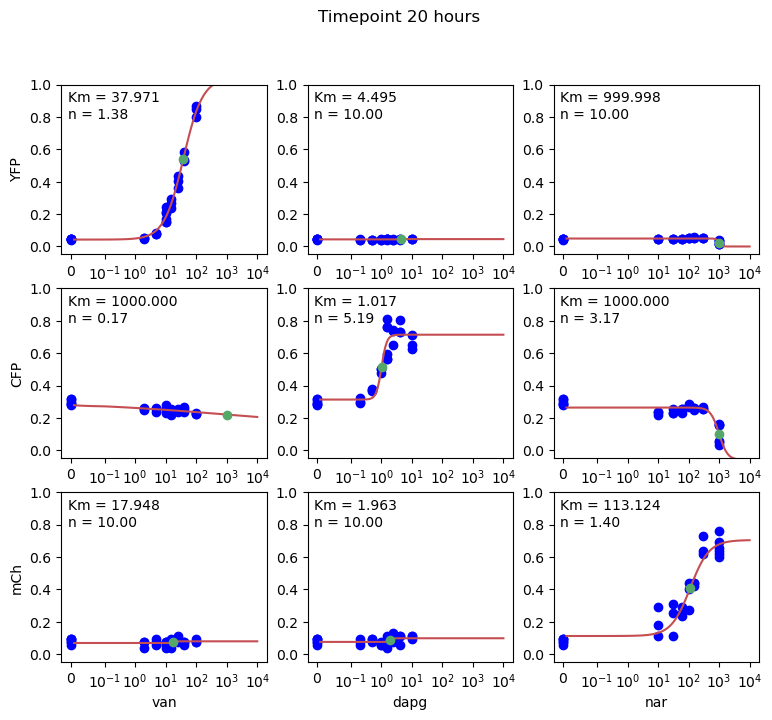

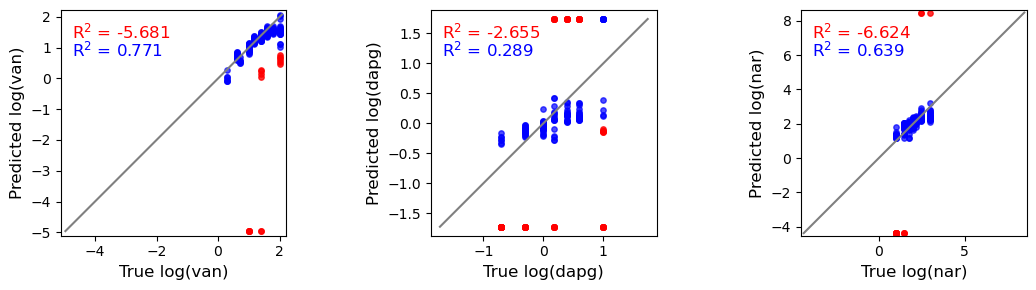

In [26]:
timepoints=[20]
num_inputs=3
num_fluors=3
fluor_inds=[0,1,2]
param_inds=[0,4,8]

remove_od_len=int(exp_data_new.shape[1]/(num_fluors+1))
fluor_data=exp_data_new[:,remove_od_len:]

hill_results=fit_hill_multiple_timepoints(timepoints, exp_inputs, fluor_data, num_inputs, num_fluors,
                                 fluor_inds, param_inds, remove_od_len)